<div class='heading'>
    <div style='float:left;'><h1>CPSC 8810 Machine Learning for Graphs</h1></div>
     <img style="float: right; padding-right: 10px" width="100" src="https://raw.githubusercontent.com/bsethwalker/clemson-cs4300/main/images/clemson_paw.png"> </div>
     </div>

**Clemson University**<br>
**Fall 2025**<br>
**Instructor(s):** Aaron Masino <br>

## Homework 5: Knowledege Graphs and GNN Applications
This homework is intended to assess your knowledge of core elements of knowledge graphs, knowledge graph reasoning, and the appllication of the heterogeneous GNNs for recommnender systems as introduced during the in-class lectures and labs. You may wish to refer to the course lectures and labs while completing this assignment.

**Unless otherwise noted in the problem instructions you may use any of the following Python libraries to complete the exercises:**
- numpy, scipy
- scikit-learn
- matplotlib, seaborn, pygraphviz
- PyTorch, PyTorch Geometric
- NetworkX

**Test code:** You may add test code after an exercise to evaluate your code. This is optional.


In [ ]:
import numpy as np
from pathlib import Path
import os

# PyTorch and PyTorch Geometric
import torch
from torch.utils.data import TensorDataset
import torch.nn.functional as F
# import torch.nn as tnn so as not to conflict with nn from PyTorch Geometric
from torch import nn as tnn
from torch_geometric.datasets import TUDataset, FakeDataset
from torch_geometric.utils import to_networkx
from torch_geometric.data import Data, HeteroData
from torch_geometric.seed import seed_everything
from torch_geometric.transforms import BaseTransform
from torch_geometric.loader import DataLoader
from torch_geometric.nn import TransformerConv, global_mean_pool

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# set device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
    
print(f"Using device: {device}")

DATA_DIR = Path('./data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 654321

---
# Part 1: Knowledge Graphs

## (2 points) Exercise 1: Number of distinct edge types in triples data
In this excercise, you are asked to complete the `num_edge_types` method. The method takes as input a collection of triples where each triple (or list) with three elements, $\left(h, r, t\right)$. The method should determine the number of distinct edge types in the knowledge graph. Your method should be **not** assume that the $h$, $r$, and $t$ values are integers. In a real-world system, these could be any Python object, for example a triple could be in the form `[string, string, string]` or `[Node, Edge, Node]`. You may assume however, that the values are hashable and can be compared for equality. 

In [ ]:
def num_edge_types(triples):
    """    
    Args:
        triples (collection of tuples/lists): List of triples where each triple is of the form (n_i, r_i, n_j) or [n_i, r_i, n_j].
    Returns:
        int: Number of distinct edge types.
    """
    ########## YOUR CODE HERE  ##########


    #####################################

In [ ]:
assert num_edge_types([[0, 'likes', 1], [1, 'follows', 2], [2, 'likes', 0]]) == 2
assert num_edge_types([(0, 0, 1), (1, 1, 2), (2, 0, 0), (3, 2, 4)]) == 3
class Node():
    def __init__(self, id):
        self.id = id
    def __eq__(self, other):
        return self.id == other.id
    def __hash__(self):
        return hash(self.id)
class Relation():
    def __init__(self, id):
        self.id = id
    def __eq__(self, other):
        return self.id == other.id
    def __hash__(self):
        return hash(self.id)
assert num_edge_types([[Node(0), Relation('friend'), Node(1)],
                        [Node(1), Relation('colleague'), Node(2)],
                        [Node(2), Relation('friend'), Node(0)],
                        [Node(3), Relation('family'), Node(4)]]) == 3

## (3 points) Excercise 2: TransR score function

In this excercise, you are asked to complete the `dist_transr` method which implements the TransR scoring function given input embeddings `eh`, `er`, `et` for the head, relation, and tail node, respectively of the triple $(h, r, t)$, and the relation matrix, `Mr`. The method should return the score for the triple. Recall that, given a triple $\left(h, r, t\right)$, with embeddings $\mathbf{h}$, $\mathbf{r}$, $\mathbf{t}$, respectively, and a relation transformation matrix, $\mathbf{M}_r$, the TransR score function, $f_r\left(h,t\right)$ = -||$\mathbf{M}_r \mathbf{h} + \mathbf{r} - \mathbf{M}_r \mathbf{t}||_2$, noting that here the $l_2$ norm is specified. 

In [ ]:
def dist_transr(eh, er, et, Mr):
    """Compute the TransR score function for a given triple.
    
    Args:
        eh (torch.Tensor): Embedding of the head entity.
        er (torch.Tensor): Embedding of the relation.
        et (torch.Tensor): Embedding of the tail entity.
        Mr (torch.Tensor): Relation-specific projection matrix.
        
    Returns:
        torch.Tensor: TransR score for the triple.
    """
    ########## YOUR CODE HERE  ##########


    #####################################

In [ ]:
eh = torch.tensor([0.1, 0.2, 0.3], dtype=torch.float32)
er = torch.tensor([0.4, 0.5, 0.6], dtype=torch.float32)
et = torch.tensor([0.7, 0.8, 0.9], dtype=torch.float32)
Mr = torch.tensor([[1.0, 0.0, 0.0],
                   [0.0, 1.0, 0.0],
                   [0.0, 0.0, 1.0]], dtype=torch.float32)
score = dist_transr(eh, er, et, Mr)
assert np.isclose(score.item(), -0.2236, atol=1e-3)

## (4 points) Excericse 3: Query2Box Box Intersection Center
In this excercise, you are asked to complete the `forward` method of the `BoxIntersectionCenter` class. The `BoxIntersectionCenter` class implements the model for estimating the center of the intersection of multiple n-dimensional boxes as proposed in the Query2Box method. Recall that each box is represented by an embedding for the center, $\mathbf{c}_{q}$, and an embedding for the offset, $\mathbf{c}_{q}$. In the Query2Box method, the center of the intersection of $I$ boxes is given as:

$\mathbf{c}_{q_{int}} = \sum_{i\in I} \mathbf{w}_i \odot \mathbf{c}_{q_i}$

where

$\mathbf{w}_i = \frac{exp\left[MLP\left( \mathbf{q}_i \right) \right]}{\sum_j exp\left[MLP\left( \mathbf{q}_j \right) \right]} $

In the `BoxIntersectionCenter` class, $MLP$ is modeled as a single fully connected linear layer, `self.lin` and the embedding dimension is `self.d`. Complete the `forward` method which takes as input `centers` and `offsets` which are PyTorch tensors representing the center and offset embeddings for the set of boxes for which the intersection is to be estimated. The `forward` method should return a single embedding representing the center of the intersection of the input boxes.

In [ ]:
class BoxIntersectionCenter(tnn.Module):
    def __init__(self, d):
        super(BoxIntersectionCenter, self).__init__()
        self.lin = tnn.Linear(2 * d, d)
        self.d = d

    def forward(self, centers, offsets):
        """Compute the intersection of multiple boxes defined by their centers and offsets.
        
        Args:
            centers (torch.Tensor): Tensor of shape (num_boxes, d) representing the centers of the boxes.
            offsets (torch.Tensor): Tensor of shape (num_boxes, d) representing the offsets (half-widths) of the boxes.
        """
        ########## YOUR CODE HERE  ##########


        #####################################


In [ ]:
seed_everything(RANDOM_SEED)
bi  = BoxIntersectionCenter(d=3)
centers = torch.tensor([[1.0, 2.0, 3.0],
                        [2.0, 3.0, 4.0]], dtype=torch.float32)
offsets = torch.tensor([[0.5, 0.5, 0.5],
                        [0.3, 0.3, 0.3]], dtype=torch.float32)
c_int = bi(centers, offsets)
np.testing.assert_array_almost_equal(c_int.detach().numpy(), np.array([1.5402, 2.3172, 3.4675]), decimal=2)

---
# Part 2: Recommender Systems

In the next series of exercies, you will build the methods needed to implement the LightGCN embedding updates for a graph based recommender system. The excercises start with the assumption that real-world system data is given as a collection of tuples where each tuple contains a User and a recommended Item. As with most real-world data, the data is not structured in a manner that allows it to be used directly in the LightGCN model.

## (3 points) Excercise 4: Bipartite node to index mappings

In this excercise, you are asked to implement the `bipartite_index_maps` which forms dictionaries that map the node sets $V_1$ and $V_2$ to integer indices, respectively. The indices are organized specifically to support development of a GNN recommender system. Recall, we modelled a GNN recommender system as a biparite graph where the set of nodes $V_1$ are entities (e.g., users) that recommend items (e.g., products) in the set of nodes $V_2$. Let $n_1$ be the number of nodes in $V_1$ and $n_2$ be the number of nodes in $V_2$. Assume we have data, `rec_data`, that is a collection of tuples of the form `(v1, v2)` that represents the relation `v1` *recommends* `v2` where where $v_1 \in V_1$ and $v_2 \in V_2$. The values of `v1` and `v2` can be **any** Python object such as `int`, `string`, etc that is hashable and can be compared for equality. To support development of a downstream GNN recommender model, the `bipartite_index_maps` method should return two dictionaries. The first, `d1`, should have keys that are the nodes in $V_1$ and values that are integers in $\left[0, n_1-1\right]$. The second, `d2`, should have keys that are the nodes in $V_2$ and values that are integers in $\left[n_1, n_1+n_2-1\right]$. Note that it does not matter which indices in $\left[0, n_1-1\right]$ are assigned to which nodes in $V_1$ or which indices in $\left[n_1, n_1+n_2-1\right]$ are assinged to which nodes in $V_2$.

In [ ]:
def bipartite_index_maps(rec_data):
    """
    Args:
        rec_data (collection of tuples/lists): Collection of tuples/lists where each tuple/list is of the form (head_node, tail_node).
    Returns:
        head_index (dict): Dictionary mapping head nodes to indices.
        tail_index (dict): Dictionary mapping tail nodes to indices.
    """
    ########## YOUR CODE HERE  ##########


    #####################################

In [ ]:
# test the function
# first build bipartite tuples where there is only one relation type and head and tail nodes do not overlap
rec_data = [(0, 3),
           (1, 4),
           (2, 5),
           (0, 4),
           (1, 5)]
head_index, tail_index = bipartite_index_maps(rec_data)
assert head_index.keys() == {0, 1, 2}
assert tail_index.keys() == {3, 4, 5}
rec_data = [['sam', 'A7KD'],
           ['alice', 'B3JF'],
           ['bob', 'C2HG'],
           ['sam', 'A7KD'],
           ['alice', 'B3JF']]
head_index, tail_index = bipartite_index_maps(rec_data)
assert head_index.keys() == {'sam', 'alice', 'bob'}
assert tail_index.keys() == {'A7KD', 'B3JF', 'C2HG'}

## (3 points) Exercise 5: Create the undirected bipartite adjacency matrix

In this excercise, you are asked to complete the `undirected_bipartite_adjacency_matrix` method which creates an adjacency matrix for a biparite graph. The method takes as input `rec_data` that is a collection of tuples of the form `(v1, v2)` that represents the relation `v1` *recommends* `v2` where where $v_1 \in V_1$ and $v_2 \in V_2$, `head_node_index_map` which is the mapping from the nodes (e.g., Users) in $V_1$ to their integer indices, and `tail_node_index_map` which is the mapping from the nodes (e.g., Products) in $V_2$ to their integer indices. The method should return a **single**, **undirected** adjacency matrix, $\mathbf{A}$, where $a_{ij}=1$ indicates there is an edge between nodes $i$ and $j$. Note, if $a_{ij}=1$ and the index $i$ refers to a node in $V_1$, then index $j$ must refer to a node in $V_2$ and vice versa. Also note that if $a_{ij}=1$ then $a_{ji}=1$. 

Assuming the `head_node_index_map` and `tail_node_index_map` assin integer indices to the nodes in $V_1$ from $\left[0, n_1-1\right]$ and indices for the nodes in $V_2$ form $\left[N_1, n_1+n_2-1\right]$ repsectively, as in Exercise 4, then the matrix returned by this method is of the following form which is what is needed for the LightGCN model:

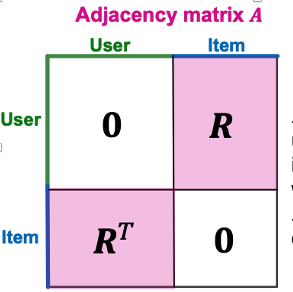

In [ ]:
def undirected_bipartite_adjacency_matrix(rec_data, head_node_index_map, tail_node_index_map):
    """
    Args:
        rec_data (list of tuples): List of tuples where each tuple is of the form (head_node, tail_node).
        head_node_index_map (dict): Mapping from head nodes to their indices.
        tail_node_index_map (dict): Mapping from tail nodes to their indices.

    Returns:
        torch.Tensor: The undirected bipartite adjacency matrix.
    """
    ########## YOUR CODE HERE  ##########


    #####################################

In [ ]:
rec_data = [[0, 3],
           [1, 4],
           [2, 5],
           [0, 4],
           [1, 5]]
head_index, tail_index = {0: 0, 1: 1, 2: 2}, {3: 3, 4: 4, 5: 5}
adj_matrix = undirected_bipartite_adjacency_matrix(rec_data, head_index, tail_index)
num_head = len(head_index)
num_tail = len(tail_index)
assert adj_matrix.shape == (num_head + num_tail, num_head + num_tail)
R1 = adj_matrix[0:num_head, num_head:].numpy()
R2 = adj_matrix[num_head:, 0:num_head].T.numpy()
np.testing.assert_array_equal(R1, R2)

rec_data = [['sam', 'A7KD'],
           ['alice', 'B3JF'],
           ['bob', 'C2HG'],
           ['sam', 'A7KD'],
           ['alice', 'B3JF']]
head_index, tail_index = {'sam': 0, 'alice': 1, 'bob': 2}, {'A7KD': 3, 'B3JF': 4, 'C2HG': 5}
adj_matrix = undirected_bipartite_adjacency_matrix(rec_data, head_index, tail_index)
num_head = len(head_index)
num_tail = len(tail_index)
assert adj_matrix.shape == (num_head + num_tail, num_head + num_tail)
R1 = adj_matrix[0:num_head, num_head:].numpy()
R2 = adj_matrix[num_head:, 0:num_head].T.numpy()
np.testing.assert_array_equal(R1, R2)

## (3 points) Exercise 6: Augmented biparite adjacency matrix

In this excercise, your asked to complete the `augmented_bipartite_adjacency_matrix` method used in the *LightGCN* method. Recall, that given the bipartite adjacency matrix, $\mathbf{A}$, the augmented adjacency matrix, $\mathbf{\tilde{A}}$, is given by 

$\mathbf{\tilde{A}} = \mathbf{D}^{-1/2} \mathbf{A} \mathbf{D}^{-1/2}$

where $\mathbf{D}$ is the diagonal matrix where $d_{ii}$ is the degree of node $i$.

In [ ]:
def augmented_bipartite_adjacency_matrix(A):
    """Construct an augmented bipartite adjacency matrix from triples data.
    
    Args:
        A (torch.Tensor): Bipartite adjacency matrix of shape (num_head + num_tail, num_head + num_tail).
    """
    ########## YOUR CODE HERE  ##########


    #####################################

In [ ]:
# test the function
A = torch.tensor([[0, 0, 0, 1, 1, 0],
                  [0, 0, 0, 0, 1, 1],
                  [0, 0, 0, 0, 0, 1],
                  [1, 0, 0, 0, 0, 0],
                  [1, 1, 0, 0, 0, 0],
                  [0, 1, 1, 0, 0, 0]], dtype=torch.float32)
aug_A = augmented_bipartite_adjacency_matrix(A)
assert aug_A.shape == A.shape
np.testing.assert_array_almost_equal(aug_A[0,:].numpy(), np.array([0.0, 0.0, 0.0, 0.7071, 0.5, 0.0]), decimal=4)
np.testing.assert_array_almost_equal(aug_A[:,0].numpy(), np.array([0.0, 0.0, 0.0, 0.7071, 0.5, 0.0]), decimal=4)

## (4 points) Exercise 7: Implement the LightGCN diffusion update
In the exercise below, you are asked to complete the `lightgcn_diffusion_update` method. Recall, in the LightGCN method we saw that the final node embeddings, $\mathbf{E}$ are generated by the diffusion equation

$\mathbf{E} = \alpha_0 \mathbf{H}^{(0)} + \alpha_1 \mathbf{\tilde{A}}\mathbf{H}^{(0)} + \alpha_1 \mathbf{\tilde{A}}^2 \mathbf{H}^{(0)} +\ldots + \alpha_L \mathbf{\tilde{A}}^L \mathbf{H}^{(0)}$

where $\mathbf{H}^{(0)}$ are the initial node embeddings, $\mathbf{\tilde{A}}$ is the augmented adjacency matrix, and $\alpha_l$ are scaling parameters. 

In your method implementation, assume $\alpha_l = \frac{1}{L+1}$ for all $l$. The method inputs are:
- `embeddings` which is the initial embeddings, $\mathbf{H}^{(0)}$
- `aug_adj_matrix` which is the augmented adjancency matrix $\mathbf{\tilde{A}}$
- `L` the number of diffusion layers

In [ ]:
def lightgcn_diffusion_update(embeddings, aug_adj_matrix, L):
    """Perform one LightGCN diffusion update step.
    
    Args:
        embeddings (torch.Tensor): Initial node embeddings of shape (num_nodes, embedding_dim).
        aug_adj_matrix (torch.Tensor): Augmented adjacency matrix of shape (num_nodes, num_nodes).
        L (int): Number of diffusion layers to apply.

    Returns:
        torch.Tensor: Updated node embeddings after one diffusion step.
    """
    ########## YOUR CODE HERE  ##########


    #####################################

In [ ]:
seed_everything(RANDOM_SEED)
num_nodes = 3
embedding_dim = 5
embeddings = torch.randn((num_nodes, embedding_dim), dtype=torch.float32)
aug_adj_matrix = torch.tensor([[0.0, 0.7071, 0.5],
                               [0.7071, 0.0, 0.5774],
                               [0.5, 0.5774, 0.0]], dtype=torch.float32)
L = 0
updated_embeddings = lightgcn_diffusion_update(embeddings, aug_adj_matrix, L)
np.testing.assert_array_almost_equal(updated_embeddings.numpy(), embeddings.numpy(), decimal=4)
L = 2
updated_embeddings = lightgcn_diffusion_update(embeddings, aug_adj_matrix, L)
print(updated_embeddings)

## (3 points) Excericse 8: HITS@K Computation
In this exercise, you are asked to implement the `hits_at_k` method. Recall, that for recommender systems the `hits@k` metric measures the proportion of samples for which the correct item is scored in the top *K* of all items when ranked by a given scoring method. For example, consider the case where there are two samples, where the correct answers are
- $v_a$ for sample 1
- $v_b$ for sample 2

Assume for each sample there are $N=100$ nodes (including the correct answer) that are scored with some some scoring function, $f$. Assuming higher scores are better, the scores are used to sort the nodes in descending order such that the node with the highest score is ranked number 1 and the node with the lowest score is ranked $N=100$ (Note, if lower scores are better, the nodes would be ranked in ascending order by the score). Assume for sample 1 that $v_a$ has rank 5 out of 100. Assume for sample 2 that $v_b$ has rank 10 out of 100. If we set K=5, then sample 1 is a *hit* because the rank of the correct item, $v_a$ is $\le5$, and sample 2 is not a hit because the rank of the correct item $v_b$ is $>5$. So the total number of hits is 1 and the total number of samples is 2, so *hits@5= (1 + 0) / 2 = 0.5*. 

The method `hits_at_k` takes as input:
- `predicted_scores` : a PyTorch tensor containing the score for each item and is of shape *(num_samples, num_items)* where *num_items* is the number of items scored for each sample. Assume higher scores are better.
- `true_indices` : a PyTorch tensor of shape *(num_samples,)* wehre `true_indices[i]` represents the index of the correct item for sample *i*
- `k` : the maximum rank of the correct item to be considered a *hit*

In [ ]:
def hits_at_k(predicted_scores, true_indices, k):
    """Compute HITS@K metric.
    
    Args:
        predicted_scores (torch.Tensor): Tensor of shape (num_samples, num_items) containing predicted scores for each item.
        true_indices (torch.Tensor): Tensor of shape (num_samples,) containing the index of the true item for each sample.
        k (int): The cutoff rank for HITS@K.
        
    Returns:
        float: HITS@K score.
    """
    ########## YOUR CODE HERE  ##########


    #####################################

In [ ]:
# test the function
predicted_scores = torch.tensor([[0.1, 0.4, 0.2, 0.3],
                                 [0.5, 0.2, 0.1, 0.4],
                                 [0.3, 0.6, 0.2, 0.1]], dtype=torch.float32)
true_indices = torch.tensor([1, 0, 2], dtype=torch.long)
assert np.isclose(hits_at_k(predicted_scores, true_indices, k=2), 2/3, atol=1e-3)
assert np.isclose(hits_at_k(predicted_scores, true_indices, k=1), 2/3, atol=1e-3)
assert np.isclose(hits_at_k(predicted_scores, true_indices, k=3), 1.0, atol=1e-3)
